## Aggregate experiment CSVs

This notebook cell searches `test/*/meta_logs/saved_csvs/*.csv`, reads the CSV files for each experiment, and builds a single pandas DataFrame where each row corresponds to one experiment. Numeric columns are averaged when a CSV has multiple rows; non-numeric columns are joined with `;`.

The aggregated table is saved to `output/aggregated_experiments.csv`.

In [13]:
import pandas as pd
from pathlib import Path
import re

root = Path('test')
experiments = []

for exp in sorted(p for p in root.iterdir() if p.is_dir()):
    saved = exp / 'meta_logs' / 'saved_csvs'
    if not saved.exists():
        continue

    row = {"experiment": exp.name.replace('test_', '')}

    for csv in sorted(saved.glob("*.csv")):
        if "VAL" in csv.stem:
            continue
        df = pd.read_csv(csv)
        if "trained_status" in df.columns:
            df_filtered = df[df["trained_status"] == "trained"]
        elif "epoch" in df.columns:
            df_filtered = df[df["epoch"] == "trained"]
        df_filtered = df_filtered.drop(columns=["epoch", "trained_status", "timestamp", ], errors='ignore').rename(columns=lambda c: re.sub(r"_level\d+", "", c))

        row[csv.stem.split("_")[0]] = df_filtered

    experiments.append(row)

df = pd.DataFrame(experiments).set_index('experiment')
df


,ConcatenateEmbeddings,MeanAggregator
experiment,,
ArcFace,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_...
Contrastive,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_...
CosFace,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_...
FastAP,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_...
Margin,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_...
Margin per Class,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_...
MultiSimilarity,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_a...
MultiSimilarity Miner,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_...
Normalized Softmax,AMI NMI mean_average_precision_...,AMI NMI mean_average_precision_...


In [14]:
df['ConcatenateEmbeddings']['ArcFace']

,AMI,NMI,mean_average_precision_at_r,precision_at_1,r_precision
2,0.795859,0.811892,0.560818,0.961901,0.626382


In [15]:
df = df.reindex(['Contrastive','Triplet','NTXent','ProxyNCA','Margin','Margin per Class','Normalized Softmax','CosFace','ArcFace','FastAP','SNR Contrastive','MultiSimilarity','MultiSimilarity Miner','SoftTriple'])

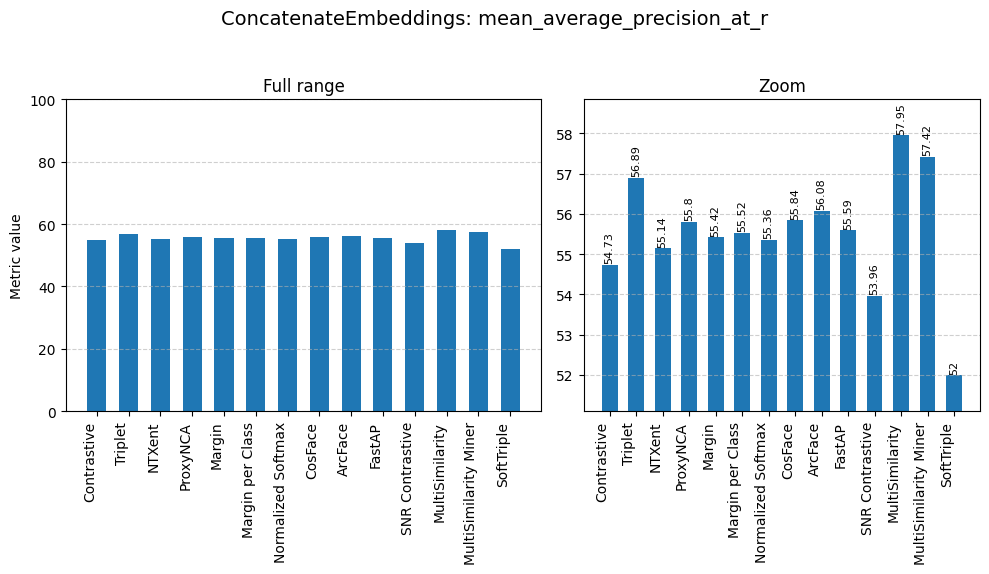

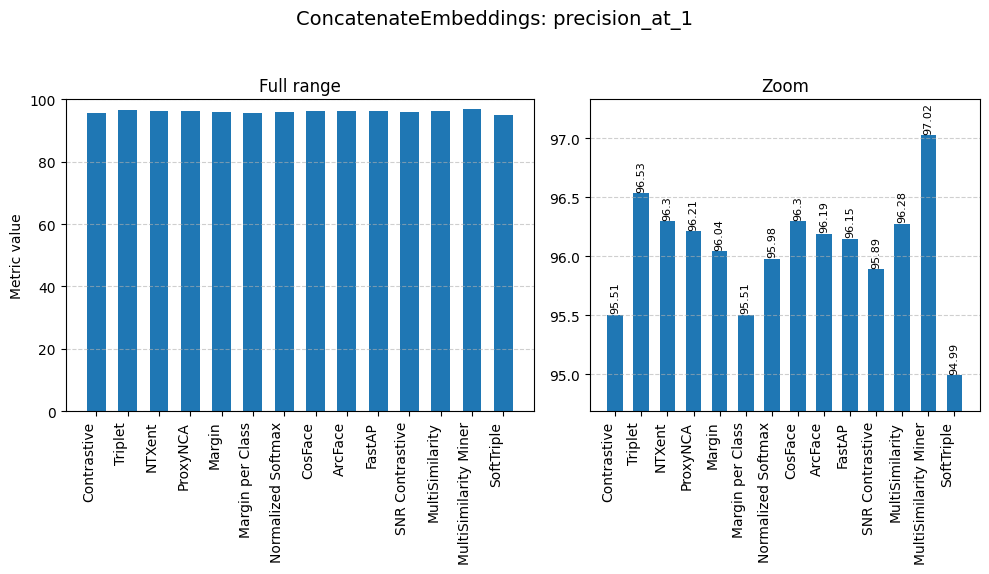

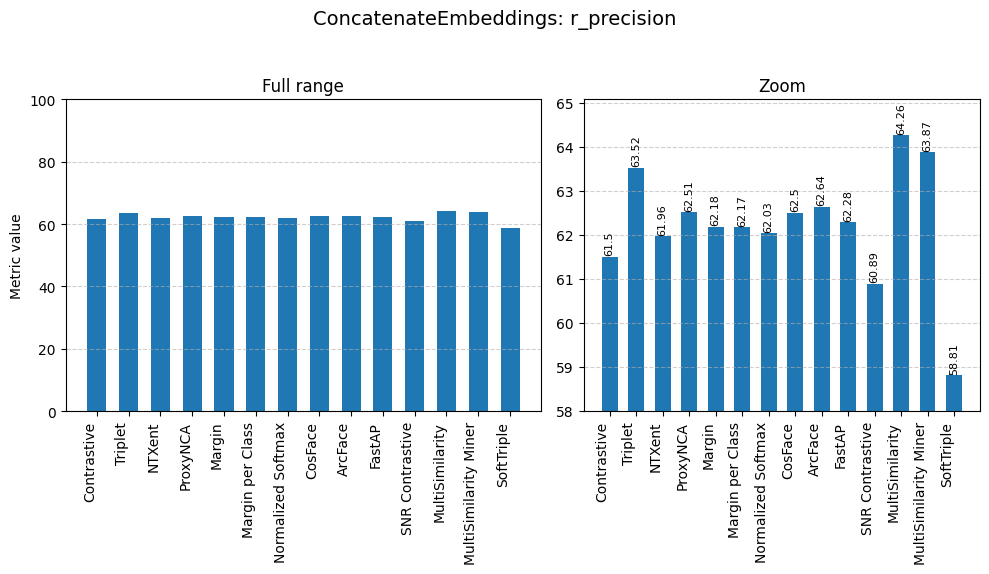

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ---- choose the aggregator you want to plot ----
aggregator = "ConcatenateEmbeddings"   # or "MeanAggregator"

# ---- metrics to plot ----
cols_to_plot = [
    'mean_average_precision_at_r',
    'precision_at_1', 
    'r_precision',
]

# keep only metrics that exist inside the nested dfs
example_inner_df = df[aggregator].iloc[0]
cols_to_plot = [c for c in cols_to_plot if c in example_inner_df.columns]

# x labels = experiment index
x_labels = df.index
x = np.arange(len(x_labels))
width = 0.6

for col in cols_to_plot:

    # ---- extract values from nested dfs ----
    values = []
    for nested in df[aggregator]:
        # handle case where nested df contains 1 row or more rows
        val = nested[col].iloc[0]
        values.append(float(val) * 100)

    values = np.array(values)
    min_val = float(values.min())
    max_val = float(values.max())

    # padding
    data_span = max_val - min_val
    pad = 0.15 * (data_span if data_span != 0 else abs(max_val) if max_val != 0 else 1.0)

    # full-range limits
    if max_val > 0:
        left_ylim = (0.0, max_val + pad)
    else:
        left_ylim = (min_val - pad, max_val + pad)

    # zoom limits
    zoom_ylim = (min_val - pad, max_val + pad)

    # figure
    fig, (ax_full, ax_zoom) = plt.subplots(
        ncols=2, figsize=(10, 6), gridspec_kw={'width_ratios': [1.2, 1]}
    )
    fig.suptitle(f'{aggregator}: {col}', fontsize=14)

    # ----- full-range plot -----
    ax_full.bar(x, values, width=width)
    ax_full.set_xticks(x)
    ax_full.set_xticklabels(x_labels, rotation=90, ha='right')
    ax_full.set_ylabel('Metric value')
    ax_full.set_ylim(0,100)
    ax_full.set_title('Full range')
    ax_full.grid(True, axis='y', linestyle='--', alpha=0.6)

    # ----- zoom plot -----
    ax_zoom.bar(x, values, width=width)
    ax_zoom.set_xticks(x)
    ax_zoom.set_xticklabels(x_labels, rotation=90, ha='right')
    ax_zoom.set_title('Zoom')
    ax_zoom.set_ylim(zoom_ylim)
    ax_zoom.grid(True, axis='y', linestyle='--', alpha=0.6)

    # annotate
    for xi, v in enumerate(values):
        va = 'bottom' if v >= 0 else 'top'
        ytext = v + 0.005 * (zoom_ylim[1] - zoom_ylim[0]) if v >= 0 else v - 0.005 * (zoom_ylim[1] - zoom_ylim[0])
        ax_zoom.text(xi, ytext, f'{v:.4g}', ha='center', va=va, fontsize=8, rotation=90)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


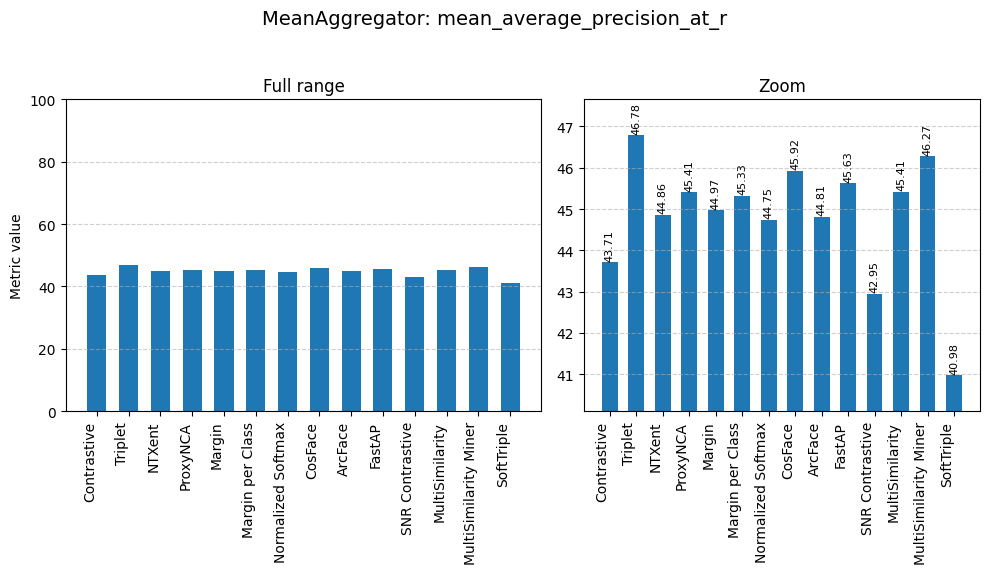

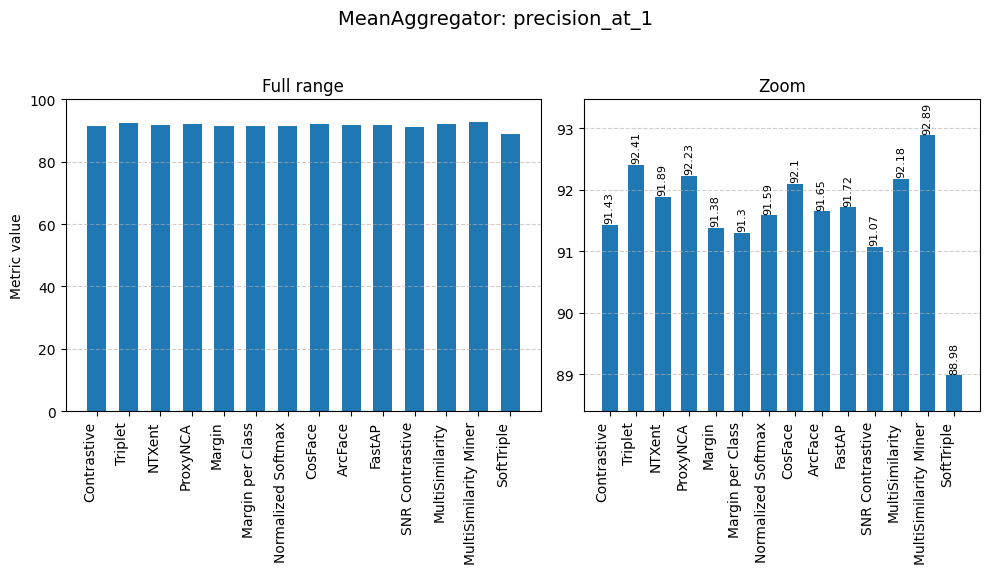

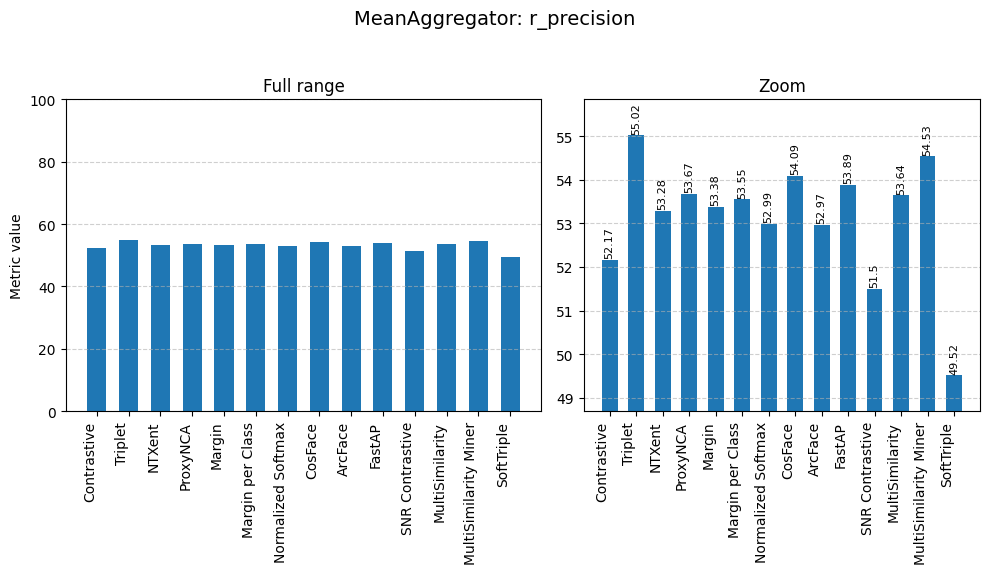

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ---- choose the aggregator you want to plot ----
aggregator =  "MeanAggregator"

# ---- metrics to plot ----
cols_to_plot = [
    'mean_average_precision_at_r',
    'precision_at_1', 
    'r_precision',
]

# keep only metrics that exist inside the nested dfs
example_inner_df = df[aggregator].iloc[0]
cols_to_plot = [c for c in cols_to_plot if c in example_inner_df.columns]

# x labels = experiment index
x_labels = df.index
x = np.arange(len(x_labels))
width = 0.6

for col in cols_to_plot:

    # ---- extract values from nested dfs ----
    values = []
    for nested in df[aggregator]:
        # handle case where nested df contains 1 row or more rows
        val = nested[col].iloc[0]
        values.append(float(val) * 100)

    values = np.array(values)
    min_val = float(values.min())
    max_val = float(values.max())

    # padding
    data_span = max_val - min_val
    pad = 0.15 * (data_span if data_span != 0 else abs(max_val) if max_val != 0 else 1.0)

    # full-range limits
    if max_val > 0:
        left_ylim = (0.0, max_val + pad)
    else:
        left_ylim = (min_val - pad, max_val + pad)

    # zoom limits
    zoom_ylim = (min_val - pad, max_val + pad)

    # figure
    fig, (ax_full, ax_zoom) = plt.subplots(
        ncols=2, figsize=(10, 6), gridspec_kw={'width_ratios': [1.2, 1]}
    )
    fig.suptitle(f'{aggregator}: {col}', fontsize=14)

    # ----- full-range plot -----
    ax_full.bar(x, values, width=width)
    ax_full.set_xticks(x)
    ax_full.set_xticklabels(x_labels, rotation=90, ha='right')
    ax_full.set_ylabel('Metric value')
    ax_full.set_ylim(0,100)
    ax_full.set_title('Full range')
    ax_full.grid(True, axis='y', linestyle='--', alpha=0.6)

    # ----- zoom plot -----
    ax_zoom.bar(x, values, width=width)
    ax_zoom.set_xticks(x)
    ax_zoom.set_xticklabels(x_labels, rotation=90, ha='right')
    ax_zoom.set_title('Zoom')
    ax_zoom.set_ylim(zoom_ylim)
    ax_zoom.grid(True, axis='y', linestyle='--', alpha=0.6)

    # annotate
    for xi, v in enumerate(values):
        va = 'bottom' if v >= 0 else 'top'
        ytext = v + 0.005 * (zoom_ylim[1] - zoom_ylim[0]) if v >= 0 else v - 0.005 * (zoom_ylim[1] - zoom_ylim[0])
        ax_zoom.text(xi, ytext, f'{v:.4g}', ha='center', va=va, fontsize=8, rotation=90)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [18]:
concatenate_df = pd.concat(
    [inner_df.assign(experiment=idx) 
     for idx, inner_df in df['ConcatenateEmbeddings'].items()],
    ignore_index=True
).set_index('experiment')

meanagg_df = pd.concat(
    [inner_df.assign(experiment=idx) 
     for idx, inner_df in df['MeanAggregator'].items()],
    ignore_index=True
).set_index('experiment')

concatenate_df

,AMI,NMI,mean_average_precision_at_r,precision_at_1,r_precision
experiment,,,,,
Contrastive,0.800286,0.816014,0.547330,0.955051,0.615013
Triplet,0.818139,0.832299,0.568917,0.965325,0.635172
NTXent,0.804385,0.819511,0.551433,0.962971,0.619639
ProxyNCA,0.817324,0.831653,0.558034,0.962115,0.625077
Margin,0.809191,0.824053,0.554210,0.960402,0.621813
Margin per Class,0.794227,0.810353,0.555247,0.955051,0.621709
Normalized Softmax,0.813352,0.828019,0.553561,0.959760,0.620274
CosFace,0.831207,0.844478,0.558438,0.962971,0.624993
ArcFace,0.795859,0.811892,0.560818,0.961901,0.626382


In [19]:
contrastive_concatenated = concatenate_df['precision_at_1']['Contrastive']
contrastive_meanagg = meanagg_df['precision_at_1']['Contrastive']
triplet_concatenated = concatenate_df['precision_at_1']['Triplet']
triplet_meanagg = meanagg_df['precision_at_1']['Triplet']
contrastive_concatenated_mean_improvement = ((concatenate_df.drop(['Contrastive','Triplet',  'SoftTriple'], axis=0)['precision_at_1']-contrastive_concatenated)/contrastive_concatenated).mean()*100
triplet_concatenated_mean_improvement = ((concatenate_df.drop(['Contrastive','Triplet',  'SoftTriple'], axis=0)['precision_at_1']-triplet_concatenated)/triplet_concatenated).mean()*100
contrastive_meanagg_mean_improvement = ((meanagg_df.drop(['Contrastive','Triplet',  'SoftTriple'], axis=0)['precision_at_1']-contrastive_meanagg)/contrastive_meanagg).mean()*100
triplet_meanagg_mean_improvement = ((meanagg_df.drop(['Contrastive','Triplet',  'SoftTriple'], axis=0)['precision_at_1']-triplet_meanagg)/triplet_meanagg).mean()*100
contrastive_concatenated_mean_improvement, triplet_concatenated_mean_improvement, contrastive_meanagg_mean_improvement, triplet_meanagg_mean_improvement

(np.float64(0.6947557149260467),
 np.float64(-0.3769401330376938),
 np.float64(0.42190501018849297),
 np.float64(-0.6364531293594949))

In [20]:
root = Path('test')
experiments = []

for exp in sorted(p for p in root.iterdir() if p.is_dir()):
    saved = exp / 'meta_logs' / 'saved_csvs'
    if not saved.exists():
        continue

    row = {"experiment": exp.name.replace('test_', '')}

    for csv in sorted(saved.glob("*.csv")):
        if "VAL" in csv.stem:
            continue
        df = pd.read_csv(csv)
        if "trained_status" in df.columns:
            df_filtered = df[df["trained_status"] == "untrained_trunk_and_embedder"]
        elif "epoch" in df.columns:
            df_filtered = df[df["epoch"] == "untrained_trunk_and_embedder"]
        df_filtered = df_filtered.drop(columns=["epoch", "trained_status", "timestamp", ], errors='ignore').rename(columns=lambda c: re.sub(r"_level\d+", "", c))

        row[csv.stem.split("_")[0]] = df_filtered

    experiments.append(row)

pretrained_df = pd.DataFrame(experiments).set_index('experiment')
meanagg_df.loc['Pretrained'] = pretrained_df.loc['ArcFace']['MeanAggregator'].iloc[0]
concatenate_df.loc['Pretrained'] = pretrained_df.loc['ArcFace']['ConcatenateEmbeddings'].iloc[0]


In [21]:
meanagg_df 

,AMI,NMI,mean_average_precision_at_r,precision_at_1,r_precision,SEM_AMI,SEM_NMI,SEM_mean_average_precision_at_r,SEM_precision_at_1,SEM_r_precision
experiment,,,,,,,,,,
Contrastive,0.697569,0.721344,0.437145,0.914330,0.521689,0.012803,0.011784,0.009349,0.001842,0.009007
Triplet,0.750770,0.770322,0.467842,0.924069,0.550177,0.002863,0.002678,0.003044,0.001117,0.002372
NTXent,0.735953,0.756643,0.448638,0.918878,0.532845,0.008271,0.007662,0.008776,0.003409,0.008413
ProxyNCA,0.743460,0.763627,0.454066,0.922303,0.536743,0.005225,0.004818,0.002749,0.002558,0.002495
Margin,0.731019,0.752113,0.449684,0.913848,0.533809,0.009411,0.008675,0.007176,0.003567,0.006684
Margin per Class,0.729979,0.751182,0.453257,0.913046,0.535542,0.001762,0.001644,0.003557,0.002486,0.002933
Normalized Softmax,0.733319,0.754279,0.447458,0.915882,0.529922,0.013006,0.011981,0.010371,0.005888,0.009731
CosFace,0.760941,0.779722,0.459237,0.920965,0.540880,0.002687,0.002467,0.004767,0.003972,0.004640
ArcFace,0.743981,0.764079,0.448087,0.916524,0.529715,0.013241,0.012224,0.008581,0.002990,0.007779


In [22]:
pretrained_df.loc['ArcFace']['MeanAggregator']

,AMI,NMI,mean_average_precision_at_r,precision_at_1,r_precision,SEM_AMI,SEM_NMI,SEM_mean_average_precision_at_r,SEM_precision_at_1,SEM_r_precision
1,0.666976,0.693115,0.327547,0.860606,0.419685,0.005422,0.005042,0.00499,0.004234,0.004635


In [23]:
(meanagg_df[['precision_at_1','r_precision','mean_average_precision_at_r']]*100).to_latex('meanagg_table.tex', float_format="%.2f")
(concatenate_df[['precision_at_1','r_precision','mean_average_precision_at_r']]*100).to_latex('concatenate_table.tex', float_format="%.2f")